In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

In [2]:
N = 1000
np.random.seed(42)

x = np.sort(5 * np.random.rand(N, 1), axis=0)
y = np.sin(x).ravel()
y_orig = np.sin(x).ravel()

# Add noise to targets.
y += 0.1*np.random.randn(N)

# Split data into train and test subsets.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

## Classificação k-NN Regressor

In [3]:
# Set parameters for grid-search.
param_grid = [{'weights': ['uniform', 'distance'], 'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]}]
clf = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, verbose=3, n_jobs=-1)
clf.fit(x_train, y_train)

print('- Número de Vizinhos mais proximos [k]:', clf.best_params_.get('n_neighbors'))
print('- Peso de cada Vizinho dado por: ', clf.best_params_.get('weights'))
print('- Precisão do Classificador', clf.best_score_)

y_pred = clf.predict(x_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


- Número de Vizinhos mais proximos [k]: 20
- Peso de cada Vizinho dado por:  uniform
- Precisão do Classificador 0.9796209553627315


[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done 105 out of 120 | elapsed:    1.4s remaining:    0.1s
[Parallel(n_jobs=-1)]: Done 120 out of 120 | elapsed:    1.4s finished


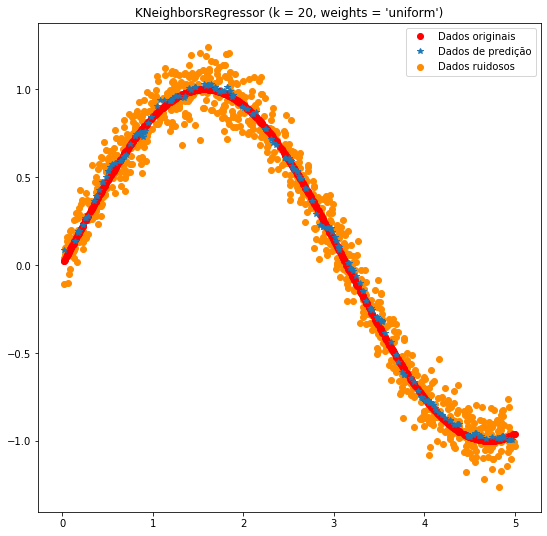

In [4]:
plt.figure(figsize=(9,9))
plt.plot(x, y_orig, 'or', label='Dados originais')
plt.scatter(x, y, color='darkorange', label='Dados ruidosos')
plt.plot(x_test, y_pred, '*', label='Dados de predição')
plt.legend()
#Show the plot.
plt.title("KNeighborsRegressor (k = %i, weights = '%s')" % (clf.best_params_.get('n_neighbors'), clf.best_params_.get('weights')))
plt.show()

In [5]:
# Cálculo do erro quadrático médio

MSE = mean_squared_error(y_test, y_pred)
print('Erro Quadrático Médio (MSE) para o conjunto de validação/teste:', MSE)

Erro Quadrático Médio (MSE) para o conjunto de validação/teste: 0.010674967098626783
